# Museum Classifier — Semi-supervised: Decision Tree + Manual Self-Training

**Preprocessing pipeline:**
- **Pipeline A** — ResNet18 (pretrained CNN feature extractor) → 512-d vectors

**Strategy (per config):**
1. Split training images into labeled (small ratio) + unlabeled
2. **Manual self-training loop** (visible iteration) assigns pseudo-labels
3. Decision Tree retrained iteratively inside the loop
4. Compare against labeled-only DT baseline — evaluated on validation set

**5 configurations** varying `threshold`, `k_best`, `max_depth`, `criterion`,
and `labeled_ratio` for a multi-axis comparison.

**Dataset structure on Google Drive:**
```
MyDrive/appliedAI/
├── training/
│   ├── museum-indoor/
│   └── museum-outdoor/
├── museum_validation/
│   ├── museum-indoor/
│   └── museum-outdoor/
└── test/
```

In [ ]:
# Install missing packages (run once)
!pip install -q torch torchvision

## Environment Setup

Run this notebook **locally** or on **Google Colab** — the cell below detects the environment automatically.

- **Local**: uses `~/Documents/Prog/AppliedAI` as the base folder
- **Colab**: mounts Google Drive and uses `MyDrive/appliedAI` — upload your dataset there first

In [1]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix,
                             roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings('ignore')
import joblib


In [3]:
def _in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if _in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/appliedAI')  # ← adjust Drive path if needed
else:
    BASE_DIR = Path.home() / 'Documents' / 'Prog' / 'AppliedAI'  # local path

print(f'Running in: {"Google Colab" if _in_colab() else "local"} environment')
print(f'BASE_DIR: {BASE_DIR}')


Mounted at /content/drive
Running in: Google Colab environment
BASE_DIR: /content/drive/MyDrive/appliedAI


## Configuration

Adjust `BASE_DIR` to point to your dataset folder inside Google Drive if needed.

In [4]:
TRAIN_DIR  = BASE_DIR / 'training'
VAL_DIR    = BASE_DIR / 'museum_validation'
TEST_DIR   = BASE_DIR / 'test'
OUTPUT_DIR = BASE_DIR / 'outputs_semisupervised'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES      = ['museum-indoor', 'museum-outdoor']   # must match folder names
IMG_SIZE     = 224
BATCH_SIZE   = 32
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42

print(f'Training dir    : {TRAIN_DIR}')
print(f'Validation dir  : {VAL_DIR}')
print(f'Test dir        : {TEST_DIR}')
print(f'Device          : {DEVICE}')
CHECKPOINT_DIR = BASE_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoint file paths — shared with supervised notebook where possible
CKPT_RESNET_TRAIN  = CHECKPOINT_DIR / 'sup_resnet_train.npz'   # reused if supervised ran first
CKPT_RESNET_VAL    = CHECKPOINT_DIR / 'sup_resnet_val.npz'
# precision/recall keys after the manual self-training refactor.
CKPT_MODELS_SEMI_R = CHECKPOINT_DIR / 'semi_models_resnet_v2.joblib'


Training dir    : /content/drive/MyDrive/appliedAI/training
Validation dir  : /content/drive/MyDrive/appliedAI/museum_validation
Test dir        : /content/drive/MyDrive/appliedAI/test
Device          : cpu


## Dataset Loader

In [5]:
class MuseumDataset(Dataset):
    """Loads labeled images from a root folder containing one sub-folder per class."""
    def __init__(self, root: Path, classes: list, transform=None):
        self.samples, self.transform = [], transform
        for idx, cls in enumerate(classes):
            d = root / cls
            if not d.exists():
                print(f'[WARN] Folder not found: {d}'); continue
            for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp'):
                for p in d.glob(ext):
                    self.samples.append((p, idx))
        self.samples.sort(key=lambda x: str(x[0]))
        counts = {cls: sum(1 for _, l in self.samples if l == i)
                  for i, cls in enumerate(classes)}
        print(f'  {root.name}: {len(self.samples)} images — ' +
              ', '.join(f'{cls}={n}' for cls, n in counts.items()))

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label


In [7]:
print('Loading datasets...')
train_dataset = MuseumDataset(TRAIN_DIR, CLASSES)
val_dataset   = MuseumDataset(VAL_DIR,   CLASSES)

if len(train_dataset) == 0:
    raise RuntimeError('No training images found — check TRAIN_DIR.')
if len(val_dataset) == 0:
    raise RuntimeError('No validation images found — check VAL_DIR.')

Loading datasets...
  training: 10000 images — museum-indoor=5000, museum-outdoor=5000
  museum_validation: 200 images — museum-indoor=100, museum-outdoor=100


## Step 1-A — Image Preprocessing: ResNet18 (512-d)

Pretrained ResNet18 with the classification head replaced by `nn.Identity()`.
Each image → 512-dimensional embedding. Run separately on training and validation sets.

In [8]:
def _load_npz(path):
    d = np.load(path)
    return d['X'], d['y']

def _save_npz(path, X, y):
    np.savez_compressed(path, X=X, y=y)
    print(f'  [CKPT] Saved → {path}')

def extract_resnet_features(dataset, ckpt_path=None):
    if ckpt_path and ckpt_path.exists():
        print(f'  Loading from checkpoint: {ckpt_path.name}')
        X, y = _load_npz(ckpt_path)
        print(f'    shape={X.shape}')
        return X, y
    resnet_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    dataset.transform = resnet_tf
    backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone.fc = nn.Identity()
    backbone.eval().to(DEVICE)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    feats_l, labels_l = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            feats_l.append(backbone(imgs.to(DEVICE)).cpu().numpy())
            labels_l.append(lbls.numpy() if isinstance(lbls, torch.Tensor) else np.array(lbls))
    dataset.transform = None
    X = np.concatenate(feats_l)
    y = np.concatenate(labels_l)
    print(f'    shape={X.shape}')
    if ckpt_path:
        _save_npz(ckpt_path, X, y)
    return X, y

print('[STEP 1-A] Extracting ResNet18 features...')
print('  Training set:')
X_resnet_train, y_train = extract_resnet_features(train_dataset, CKPT_RESNET_TRAIN)
print('  Validation set:')
X_resnet_val,   y_val   = extract_resnet_features(val_dataset,   CKPT_RESNET_VAL)

[STEP 1-A] Extracting ResNet18 features...
  Training set:
  Loading from checkpoint: sup_resnet_train.npz
    shape=(10000, 512)
  Validation set:
  Loading from checkpoint: sup_resnet_val.npz
    shape=(200, 512)


## Semi-supervised Split Helper

Stratified split applied to the **training set only**: a given ratio per class
receives real labels; the rest are marked unlabeled and become input for the
self-training loop. The validation set is always fully labeled and used only
for final evaluation.

In [9]:
def make_semisup_split(y, labeled_ratio, rng_seed):
    """Stratified split: labeled_ratio% per class gets a real label, rest = -1."""
    rng = np.random.RandomState(rng_seed)
    labeled_idx = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        n_lab   = max(1, int(len(cls_idx) * labeled_ratio))
        labeled_idx.extend(rng.choice(cls_idx, n_lab, replace=False).tolist())
    labeled_idx   = np.array(labeled_idx)
    unlabeled_idx = np.setdiff1d(np.arange(len(y)), labeled_idx)
    y_semi = np.full(len(y), -1, dtype=int)
    y_semi[labeled_idx] = y[labeled_idx]
    return labeled_idx, unlabeled_idx, y_semi


## Manual Self-Training Loop — the only method used

All 5 configurations of this notebook use the manual self-training algorithm
implemented below. The class accepts these tunable parameters:

| Parameter | Effect |
|---|---|
| `max_depth` | DT capacity — shallow trees give more nuanced probas, deeper trees give more extreme probas |
| `criterion` | `'gini'` or `'entropy'` — split impurity metric |
| `min_samples_leaf` | leaf-size regularizer, prevents overfit |
| `threshold` | minimum confidence for accepting a pseudo-label |
| `k_best` | if set, accept only the top-K samples per iter (by score) — forces multi-iteration convergence even with extreme DT probas |
| `max_iter` | hard upper bound on iterations |

**Algorithm:**
1. Train DT on the current labeled pool
2. Predict probabilities on the unlabeled pool
3. **Score** each sample = max class probability
4. **Select** samples to accept as pseudo-labels:
   - *threshold mode* (`k_best=None`): all samples with score ≥ `threshold`
   - *top-K mode* (`k_best=K`): only the K highest-scoring samples among those above threshold
5. Move accepted samples to the labeled pool
6. **Stop** when any of:
   - `no_confident_samples` — no sample crossed the threshold (convergence)
   - `predictions_stable` — predictions on unlabeled set unchanged (stability)
   - `unlabeled_exhausted` — nothing left to pseudo-label
   - `max_iter_reached` — hard cap fired

Each iteration is logged in `self.history_`; the stop condition that fired is
recorded in `self.stop_reason_` — used by the Step 3-B convergence plot.

In [10]:
class ManualSelfTrainingDT:
    """
    Self-training with EXPLICIT loop, threshold-OR-top-K selection,
    and four tested convergence criteria.

    Parameters
    ----------
    max_depth        : int or None    DT capacity (None = unlimited)
    criterion        : 'gini'|'entropy'
    min_samples_leaf : int            leaf-size regularizer
    threshold        : float          confidence threshold for pseudo-acceptance
    k_best           : int or None    if set, only the top-K samples per iter
                                      (among those above threshold) are accepted
                                      — forces visible multi-iteration convergence
                                      even when DT probas are extreme (depth-2 leaves)
    max_iter         : int            hard cap on iterations
    random_state     : int
    verbose          : bool

    After fit():
        self.clf_           — final DT trained on (labeled + accepted pseudo)
        self.transduction_  — predicted labels for the full ORIGINAL unlabeled set
                              (backfilled with clf.predict for samples that
                              never crossed the threshold)
        self.pseudo_labels_ — -1 for samples never accepted, else accepted label
        self.history_       — list[dict] with one entry per iteration
        self.stop_reason_   — one of:
            'no_confident_samples' | 'predictions_stable' |
            'unlabeled_exhausted'  | 'max_iter_reached'
    """

    def __init__(self, max_depth=2, criterion='gini', min_samples_leaf=1,
                 threshold=0.75, k_best=None, max_iter=15,
                 random_state=42, verbose=True):
        self.max_depth        = max_depth
        self.criterion        = criterion
        self.min_samples_leaf = min_samples_leaf
        self.threshold        = threshold
        self.k_best           = k_best
        self.max_iter         = max_iter
        self.random_state     = random_state
        self.verbose          = verbose

    def fit(self, X_labeled, y_labeled, X_unlabeled):
        X_lab = np.asarray(X_labeled,   dtype=np.float32).copy()
        y_lab = np.asarray(y_labeled,   dtype=np.int64  ).copy()
        X_unl = np.asarray(X_unlabeled, dtype=np.float32).copy()

        orig_unl_idx  = np.arange(len(X_unl))            # track original positions
        n_orig_unl    = len(X_unl)
        pseudo_labels = np.full(len(X_unl), -1, dtype=np.int64)
        prev_snapshot = None

        self.history_     = []
        self.stop_reason_ = None
        clf               = None

        # ──────────────── EXPLICIT SELF-TRAINING LOOP ────────────────────────
        for it in range(1, self.max_iter + 1):

            # STEP 1 — train DT on the current labeled pool
            clf = DecisionTreeClassifier(
                max_depth=self.max_depth, criterion=self.criterion,
                min_samples_leaf=self.min_samples_leaf,
                random_state=self.random_state,
            )
            clf.fit(X_lab, y_lab)

            # Edge case: no unlabeled samples left
            if len(X_unl) == 0:
                self.stop_reason_ = 'unlabeled_exhausted'
                if self.verbose:
                    print(f'      [iter {it:2d}] STOP: unlabeled pool exhausted')
                break

            # STEP 2 — predict probabilities on the unlabeled pool
            probas = clf.predict_proba(X_unl)
            preds  = clf.classes_[probas.argmax(axis=1)]

            # STEP 3 — score = max class probability (works for K classes)
            scores = probas.max(axis=1)

            # STEP 4 — select samples to accept
            # First filter: must be above threshold
            threshold_mask = scores >= self.threshold

            if self.k_best is not None:
                # Top-K mode: among threshold-passing samples, keep only the
                # top K by score. Forces gradual, visible iteration even when
                # DT probas are extreme.
                eligible_idx = np.where(threshold_mask)[0]
                if len(eligible_idx) > self.k_best:
                    # argsort ascending → take last K = highest scores
                    top_in_elig = np.argsort(scores[eligible_idx])[-self.k_best:]
                    confident_mask = np.zeros_like(threshold_mask)
                    confident_mask[eligible_idx[top_in_elig]] = True
                else:
                    confident_mask = threshold_mask
            else:
                # Pure threshold mode (classic Yarowsky 1995)
                confident_mask = threshold_mask

            n_confident = int(confident_mask.sum())

            if self.verbose:
                mode_tag = f'k_best={self.k_best}' if self.k_best is not None else 'threshold'
                print(f'      [iter {it:2d}]  labeled_pool={len(X_lab):5d}  '
                      f'unlabeled_left={len(X_unl):5d}  '
                      f'confident_new={n_confident:5d}  '
                      f'avg_score={scores.mean():.3f}  '
                      f'max_score={scores.max():.3f}  ({mode_tag})')

            # ── CONVERGENCE TEST #1: no confident samples this round ─────────
            if n_confident == 0:
                self.stop_reason_ = 'no_confident_samples'
                if self.verbose:
                    print(f'      [iter {it:2d}] STOP (convergence): no sample '
                          f'exceeded threshold={self.threshold}')
                break

            # ── CONVERGENCE TEST #2: predictions on unlabeled set stable ─────
            # Use a fixed-size snapshot indexed by original positions so the
            # comparison is valid across iterations even as X_unl shrinks.
            snapshot = np.full(n_orig_unl, -1, dtype=np.int64)
            snapshot[orig_unl_idx] = preds
            if prev_snapshot is not None and np.array_equal(snapshot, prev_snapshot):
                self.stop_reason_ = 'predictions_stable'
                if self.verbose:
                    print(f'      [iter {it:2d}] STOP (stability): predictions '
                          f'on unlabeled set unchanged from previous iter')
                break
            prev_snapshot = snapshot

            # STEP 5 — move confident samples from unlabeled to labeled
            X_lab = np.vstack([X_lab, X_unl[confident_mask]])
            y_lab = np.concatenate([y_lab, preds[confident_mask]])
            pseudo_labels[orig_unl_idx[confident_mask]] = preds[confident_mask]

            X_unl        = X_unl[~confident_mask]
            orig_unl_idx = orig_unl_idx[~confident_mask]

            self.history_.append(dict(
                iter=it, labeled_size=len(X_lab),
                unlabeled_left=len(X_unl),
                n_confident_added=n_confident,
                avg_score=float(scores.mean()),
                max_score=float(scores.max()),
                threshold=self.threshold,
                k_best=self.k_best,
            ))
        else:
            # for-else: max_iter reached without break
            self.stop_reason_ = 'max_iter_reached'
            if self.verbose:
                print(f'      STOP: max_iter={self.max_iter} reached without convergence')

        # Backfill transduction_ for unlabeled samples never accepted
        unlabeled_full_pred = clf.predict(np.asarray(X_unlabeled, dtype=np.float32))
        self.transduction_  = np.where(pseudo_labels == -1,
                                        unlabeled_full_pred,
                                        pseudo_labels)
        self.pseudo_labels_ = pseudo_labels
        self.clf_           = clf
        return self

    def predict(self, X):
        return self.clf_.predict(X)

    def predict_proba(self, X):
        return self.clf_.predict_proba(X)


## Step 2 — 5 Self-Training Configurations

All 5 configs use the `ManualSelfTrainingDT` from above. They vary along
**five orthogonal axes** so the comparison isolates the effect of each:

| Config | `labeled_ratio` | `dt_depth` | `criterion` | `threshold` | `k_best` | `max_iter` |
|---|---|---|---|---|---|---|
| **ST_thr075_d2_lab20** (baseline) | 20% | 2 | gini    | 0.75 | None | 15 |
| **ST_thr095_d6_lab10** (strict)   | 10% | 6 | gini    | 0.95 | None | 15 |
| **ST_kbest500_d4_lab20** (top-K)  | 20% | 4 | gini    | 0.75 | 500  | 20 |
| **ST_entropy_d4_lab30** (entropy) | 30% | 4 | entropy | 0.60 | None | 15 |
| **ST_thr060_d6_lab30** (lenient)  | 30% | 6 | gini    | 0.60 | None | 15 |

**What each config tests:**
- *baseline* — reference point with moderate everything
- *strict* — small labeled fraction + high threshold → tests robustness with little data
- *top-K* — forces gradual iteration even when DT probas are extreme; demonstrates k_best mode
- *entropy* — same as baseline but with entropy criterion → isolates criterion effect
- *lenient* — low threshold + deeper tree + more labeled → aggressive pseudo-rotulagem


In [11]:
# 5 self-training configurations varying labeled_ratio, dt_depth, criterion,
# threshold, k_best, and max_iter for multi-axis comparison.
SEMISUP_CONFIGS = [
    # ── Baseline — moderate everything, threshold mode ─────────────────────
    dict(name='ST_thr075_d2_lab20',
         labeled_ratio=0.20, dt_depth=2, criterion='gini',
         min_samples_leaf=1, threshold=0.75, k_best=None, max_iter=15),

    # ── Strict — small labeled, very high threshold ────────────────────────
    dict(name='ST_thr095_d6_lab10',
         labeled_ratio=0.10, dt_depth=6, criterion='gini',
         min_samples_leaf=3, threshold=0.95, k_best=None, max_iter=15),

    # ── Top-K mode — forces gradual multi-iteration convergence ────────────
    dict(name='ST_kbest500_d4_lab20',
         labeled_ratio=0.20, dt_depth=4, criterion='gini',
         min_samples_leaf=1, threshold=0.75, k_best=500, max_iter=20),

    # ── Entropy criterion — same as baseline but criterion='entropy' ──────
    dict(name='ST_entropy_d4_lab30',
         labeled_ratio=0.30, dt_depth=4, criterion='entropy',
         min_samples_leaf=3, threshold=0.60, k_best=None, max_iter=15),

    # ── Lenient + deeper tree — aggressive pseudo-labeling ────────────────
    dict(name='ST_thr060_d6_lab30',
         labeled_ratio=0.30, dt_depth=6, criterion='gini',
         min_samples_leaf=4, threshold=0.60, k_best=None, max_iter=15),
]


In [12]:
def run_semisup_pipeline(X_train: np.ndarray, y_train: np.ndarray,
                          X_val:   np.ndarray, y_val:   np.ndarray,
                          pipe_label: str, ckpt_path=None) -> tuple:
    """
    All-self-training pipeline:
      Scale → ManualSelfTrainingDT.fit() → eval on val.

    No PCA is applied (DT scales linearly in d, so 512-d works fine).
    Incremental checkpoint: trains only configs missing from saved results;
    removes stale configs from the cache.
    """
    results = {}
    scaler  = None

    # ── Load existing checkpoint (may be partial) ───────────────────────────
    if ckpt_path and ckpt_path.exists():
        payload = joblib.load(ckpt_path)
        results = dict(payload.get('results', {}))
        scaler  = payload.get('scaler', None)
        if results:
            print(f'\n[STEP 2] Checkpoint loaded: {ckpt_path.name}')
            current_names = {c['name'] for c in SEMISUP_CONFIGS}
            for stale in [n for n in list(results) if n not in current_names]:
                del results[stale]
                print(f'  [REMOVED] {stale}  (no longer in SEMISUP_CONFIGS)')
            for name, r in results.items():
                print(f'  [LOADED] {name}  Acc={r["acc"]:.4f}  '
                      f'F1={r["f1"]:.4f}  ΔF1={r["f1"]-r["f1_base"]:+.4f}')

    # ── Configs missing from checkpoint ─────────────────────────────────────
    missing = [c for c in SEMISUP_CONFIGS if c['name'] not in results]
    if not missing:
        print('  [CKPT] All configs already trained — nothing to do.')
        return results, scaler

    # ── Scale only (no PCA — DT scales linearly with d) ─────────────────────
    if scaler is None:
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
    else:
        X_train_sc = scaler.transform(X_train)
    X_val_sc = scaler.transform(X_val)

    print(f'\n{"-"*64}')
    print(f'  {pipe_label}')
    print(f'  features={X_train.shape[1]}  train={len(X_train)}  val={len(X_val)}')
    print(f'  Training {len(missing)} new config(s): {[c["name"] for c in missing]}')
    print(f'{"-"*64}')

    # ── Loop over missing configs ───────────────────────────────────────────
    for cfg in missing:
        name             = cfg['name']
        labeled_ratio    = cfg['labeled_ratio']
        dt_depth         = cfg['dt_depth']
        criterion        = cfg.get('criterion', 'gini')
        min_samples_leaf = cfg.get('min_samples_leaf', 1)
        threshold        = cfg.get('threshold', 0.75)
        k_best           = cfg.get('k_best')
        max_iter_st      = cfg.get('max_iter', 15)

        print(f'\n  [CONFIG] {name}')
        print(f'    labeled_ratio={labeled_ratio:.0%}  depth={dt_depth}  '
              f'criterion={criterion}  threshold={threshold}  '
              f'k_best={k_best}  max_iter={max_iter_st}')
        t0 = time.time()

        labeled_idx, unlabeled_idx, y_semi = make_semisup_split(
            y_train, labeled_ratio, RANDOM_STATE)
        print(f'    Labeled={len(labeled_idx)}  Unlabeled={len(unlabeled_idx)}')

        # ── Manual self-training loop ──────────────────────────────────────
        print(f'    --- Manual self-training loop ---')
        stm = ManualSelfTrainingDT(
            max_depth=dt_depth, criterion=criterion,
            min_samples_leaf=min_samples_leaf,
            threshold=threshold, k_best=k_best, max_iter=max_iter_st,
            random_state=RANDOM_STATE, verbose=True,
        )
        stm.fit(
            X_labeled  = X_train_sc[labeled_idx],
            y_labeled  = y_train[labeled_idx],
            X_unlabeled= X_train_sc[unlabeled_idx],
        )
        print(f'    --- Stop reason: {stm.stop_reason_}  '
              f'(iterations completed = {len(stm.history_)}) ---')

        # Pseudo-label accuracy on the unlabeled set (uses backfilled transduction_)
        pseudo_unlab = stm.transduction_
        pseudo_acc   = accuracy_score(y_train[unlabeled_idx], pseudo_unlab)
        print(f'    Pseudo-label accuracy on unlabeled set: {pseudo_acc:.4f}')

        # ── Labeled-only baseline DT (no self-training) for ΔF1 ────────────
        dt_base = DecisionTreeClassifier(
            max_depth=dt_depth, criterion=criterion,
            min_samples_leaf=min_samples_leaf, random_state=RANDOM_STATE,
        )
        dt_base.fit(X_train_sc[labeled_idx], y_train[labeled_idx])
        y_pred_base = dt_base.predict(X_val_sc)
        f1_base = f1_score(y_val, y_pred_base, average='macro', zero_division=0)

        # ── Validation metrics — use stm.clf_ (final self-training model) ──
        y_pred  = stm.predict(X_val_sc)
        y_proba = stm.predict_proba(X_val_sc)[:, 1]

        acc                 = accuracy_score(y_val, y_pred)
        f1_macro            = f1_score(y_val, y_pred, average='macro', zero_division=0)
        precision_macro     = precision_score(y_val, y_pred, average='macro', zero_division=0)
        recall_macro        = recall_score(y_val, y_pred, average='macro', zero_division=0)
        precision_per_class = precision_score(y_val, y_pred, average=None, zero_division=0)
        recall_per_class    = recall_score(y_val, y_pred, average=None, zero_division=0)
        f1_per_class        = f1_score(y_val, y_pred, average=None, zero_division=0)
        fpr, tpr, _         = roc_curve(y_val, y_proba)
        roc_auc             = auc(fpr, tpr)
        elapsed             = time.time() - t0

        results[name] = dict(
            dt=stm.clf_, scaler=scaler, method='ST_MANUAL',
            acc=acc, f1=f1_macro, f1_base=f1_base, roc_auc=roc_auc,
            precision_macro=precision_macro, recall_macro=recall_macro,
            precision_per_class=precision_per_class,
            recall_per_class=recall_per_class,
            f1_per_class=f1_per_class,
            fpr=fpr, tpr=tpr, cm=confusion_matrix(y_val, y_pred),
            y_pred=y_pred, y_proba=y_proba, y_test=y_val,
            pseudo_acc=pseudo_acc, n_lab=len(labeled_idx),
            n_unlab=len(unlabeled_idx), labeled_ratio=labeled_ratio,
            time=elapsed, st_history=stm.history_, stop_reason=stm.stop_reason_,
            # config metadata for the report table
            cfg_depth=dt_depth, cfg_criterion=criterion,
            cfg_threshold=threshold, cfg_k_best=k_best, cfg_max_iter=max_iter_st,
            report=classification_report(y_val, y_pred, target_names=CLASSES),
        )
        print(f'    Acc={acc:.4f}  F1macro={f1_macro:.4f}  '
              f'P={precision_macro:.4f}  R={recall_macro:.4f}  '
              f'ΔF1={f1_macro-f1_base:+.4f}  AUC={roc_auc:.4f}  t={elapsed:.1f}s')

    # ── Save updated checkpoint ─────────────────────────────────────────────
    if ckpt_path:
        joblib.dump({'results': results, 'scaler': scaler}, ckpt_path)
        print(f'  [CKPT] Saved → {ckpt_path}')
    return results, scaler


In [13]:
# ── PIPELINE A ─ Run (or load from checkpoint) ──────────────────────────────
print('=' * 64)
print('  Running Pipeline A — ResNet18 (semi-supervised)')
print('=' * 64)
# ResNet features: 512-d  |  saves to CKPT_MODELS_SEMI_R
res_r, sc_r = run_semisup_pipeline(
    X_resnet_train, y_train, X_resnet_val, y_val,
    'Pipeline A — ResNet18', CKPT_MODELS_SEMI_R
)
print('\n[Pipeline A done — checkpoint saved. You can stop here and resume later.]')


  Running Pipeline A — ResNet18 (semi-supervised)

----------------------------------------------------------------
  Pipeline A — ResNet18
  features=512  train=10000  val=200
  Training 5 new config(s): ['ST_thr075_d2_lab20', 'ST_thr095_d6_lab10', 'ST_kbest500_d4_lab20', 'ST_entropy_d4_lab30', 'ST_thr060_d6_lab30']
----------------------------------------------------------------

  [CONFIG] ST_thr075_d2_lab20
    labeled_ratio=20%  depth=2  criterion=gini  threshold=0.75  k_best=None  max_iter=15
    Labeled=2000  Unlabeled=8000
    --- Manual self-training loop ---
      [iter  1]  labeled_pool= 2000  unlabeled_left= 8000  confident_new= 7539  avg_score=0.915  max_score=0.940  (threshold)
      [iter  2]  labeled_pool= 9539  unlabeled_left=  461  confident_new=    4  avg_score=0.560  max_score=0.988  (threshold)
      [iter  3]  labeled_pool= 9543  unlabeled_left=  457  confident_new=    0  avg_score=0.557  max_score=0.557  (threshold)
      [iter  3] STOP (convergence): no sample e

In [14]:
# ── COMBINE RESULTS ────────────────────────────────────────────────────────
all_results = {'resnet': res_r}
scalers     = {'resnet': sc_r}
print('Results ready — generating report.')
for cn, r in all_results['resnet'].items():
    f1_delta = r['f1'] - r['f1_base']
    print(f'  {cn:35s}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  ΔF1={f1_delta:+.4f}')


Results ready — generating report.
  ST_thr075_d2_lab20                   Acc=0.9200  F1=0.9200  ΔF1=+0.0000
  ST_thr095_d6_lab10                   Acc=0.9050  F1=0.9050  ΔF1=+0.0100
  ST_kbest500_d4_lab20                 Acc=0.9300  F1=0.9300  ΔF1=+0.0100
  ST_entropy_d4_lab30                  Acc=0.9250  F1=0.9247  ΔF1=+0.0000
  ST_thr060_d6_lab30                   Acc=0.9450  F1=0.9449  ΔF1=-0.0050


## Step 3 — Report

Comprehensive dashboard of the 5 self-training configurations: accuracy /
F1macro / AUC bars, F1 (semi vs labeled-only baseline), ΔF1 heatmap, ROC
curves, per-class precision/recall, pseudo-label accuracy, best confusion
matrix, labeled vs pseudo-labeled counts, ratio→ΔF1 scatter, training times,
and full summary table with macro Precision/Recall and stop reason.

In [15]:
PIPE_META = {
    'resnet': {'label': 'Pipeline A — ResNet18 (512-d)', 'color': '#4FC3F7'},
}

def build_report(all_results: dict):
    cfg_names = [c['name'] for c in SEMISUP_CONFIGS]
    n         = len(cfg_names)
    palette   = sns.color_palette('Set2', n)
    color     = PIPE_META['resnet']['color']

    fig = plt.figure(figsize=(20, 36))
    fig.patch.set_facecolor('#0d0f1a')
    gs  = gridspec.GridSpec(6, 3, figure=fig, hspace=0.70, wspace=0.40)
    tkw  = dict(color='white', fontsize=10, fontweight='bold', pad=8)
    axbg = '#161929'

    def sa(ax):
        ax.set_facecolor(axbg); ax.tick_params(colors='#ccc')
        ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
        for sp in ax.spines.values(): sp.set_color('#2a2d3e')

    xlbls = [c.replace('_', '\n') for c in cfg_names]
    x, w  = np.arange(n), 0.6

    # ── Row 0: Accuracy / F1 macro / AUC bars ────────────────────────────────
    for col, (mkey, mtitle) in enumerate([('acc','Accuracy'),
                                           ('f1','F1 (macro)'),
                                           ('roc_auc','ROC-AUC')]):
        ax = fig.add_subplot(gs[0, col]); sa(ax)
        vals = [all_results['resnet'][c][mkey] for c in cfg_names]
        bars = ax.bar(x, vals, w, color=color, edgecolor='white', linewidth=0.4, alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.012,
                    f'{v:.2f}', ha='center', color='white', fontsize=6.5)
        ax.set_xticks(x); ax.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
        ax.set_ylim(0, 1.15); ax.set_title(mtitle, **tkw)

    # ── Row 1: F1 semi vs baseline (2 cols) + ΔF1 heatmap ──────────────────
    ax_f1 = fig.add_subplot(gs[1, 0:2]); sa(ax_f1)
    f1s  = [all_results['resnet'][c]['f1']      for c in cfg_names]
    f1bs = [all_results['resnet'][c]['f1_base'] for c in cfg_names]
    ax_f1.bar(x - w/4, f1s,  w/2, color=color,     label='Semi-sup DT',  alpha=0.90, edgecolor='white', lw=0.4)
    ax_f1.bar(x + w/4, f1bs, w/2, color='#F48FB1', label='Labeled-only', alpha=0.80, edgecolor='white', lw=0.4)
    ax_f1.set_xticks(x); ax_f1.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_f1.set_ylim(0, 1.12)
    ax_f1.set_title('F1 (macro): Semi-supervised vs Labeled-only Baseline', **tkw)
    ax_f1.legend(fontsize=8, facecolor='#0d0f1a', labelcolor='white')

    ax_heat = fig.add_subplot(gs[1, 2]); sa(ax_heat)
    delta_vals = np.array([[all_results['resnet'][c]['f1'] - all_results['resnet'][c]['f1_base']
                            for c in cfg_names]])
    lim = max(abs(delta_vals.min()), abs(delta_vals.max())) + 0.01
    im = ax_heat.imshow(delta_vals, cmap='RdYlGn', aspect='auto', vmin=-lim, vmax=lim)
    ax_heat.set_xticks(range(n)); ax_heat.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_heat.set_yticks([0]); ax_heat.set_yticklabels(['ResNet18'], color='#ccc', fontsize=8)
    ax_heat.set_title('ΔF1 Heatmap (Semi − Baseline)\nGreen = semi helps', **tkw)
    for j in range(n):
        ax_heat.text(j, 0, f'{delta_vals[0,j]:+.3f}', ha='center', va='center',
                     color='black', fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)

    # ── Row 2: ROC curves (2 cols) + pseudo-label accuracy ─────────────────
    ax_roc = fig.add_subplot(gs[2, 0:2]); sa(ax_roc)
    ax_roc.plot([0,1],[0,1],'w--',lw=1,alpha=0.35)
    for i, cn in enumerate(cfg_names):
        r = all_results['resnet'][cn]
        ax_roc.plot(r['fpr'], r['tpr'], color=palette[i], lw=1.8,
                    label=f'{cn} ({r["roc_auc"]:.3f})')
    ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('ROC Curves — Pipeline A: ResNet18', **tkw)
    ax_roc.legend(fontsize=6, facecolor='#0d0f1a', labelcolor='white')

    ax_pseudo = fig.add_subplot(gs[2, 2]); sa(ax_pseudo)
    pa = [all_results['resnet'][c]['pseudo_acc'] for c in cfg_names]
    bars_p = ax_pseudo.bar(x, pa, w, color=color, edgecolor='white', linewidth=0.4, alpha=0.88)
    for bar, v in zip(bars_p, pa):
        ax_pseudo.text(bar.get_x()+bar.get_width()/2, v+0.01,
                       f'{v:.3f}', ha='center', color='white', fontsize=7)
    ax_pseudo.set_xticks(x); ax_pseudo.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_pseudo.set_ylim(0, 1.1)
    ax_pseudo.set_title('Pseudo-label Accuracy\n(quality of unlabeled propagation)', **tkw)

    # ── Row 3 NEW: per-class Precision and Recall (rubric requirement) ─────
    class_colors = ['#4FC3F7', '#F48FB1']
    w2 = 0.35

    ax_prec = fig.add_subplot(gs[3, 0:2]); sa(ax_prec)
    ax_rec  = fig.add_subplot(gs[3, 2]);   sa(ax_rec)
    for ci, cls_name in enumerate(CLASSES):
        prec_vals = [all_results['resnet'][cn]['precision_per_class'][ci] for cn in cfg_names]
        rec_vals  = [all_results['resnet'][cn]['recall_per_class'][ci]    for cn in cfg_names]
        offset = (ci - 0.5) * w2
        bp = ax_prec.bar(x + offset, prec_vals, w2, label=cls_name,
                          color=class_colors[ci], edgecolor='white', linewidth=0.4, alpha=0.88)
        br = ax_rec.bar(x + offset, rec_vals, w2, label=cls_name,
                          color=class_colors[ci], edgecolor='white', linewidth=0.4, alpha=0.88)
        for bar, v in zip(bp, prec_vals):
            ax_prec.text(bar.get_x()+bar.get_width()/2, v+0.012,
                          f'{v:.2f}', ha='center', color='white', fontsize=6)
        for bar, v in zip(br, rec_vals):
            ax_rec.text(bar.get_x()+bar.get_width()/2, v+0.012,
                         f'{v:.2f}', ha='center', color='white', fontsize=6)
    ax_prec.set_xticks(x); ax_prec.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_prec.set_ylim(0, 1.25)
    ax_prec.set_title('Precision per Class', **tkw)
    ax_prec.legend(fontsize=7, facecolor='#0d0f1a', labelcolor='white')
    ax_rec.set_xticks(x); ax_rec.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_rec.set_ylim(0, 1.25)
    ax_rec.set_title('Recall per Class', **tkw)
    ax_rec.legend(fontsize=7, facecolor='#0d0f1a', labelcolor='white')

    # ── Row 4: best CM + labeled/pseudo counts + ratio → ΔF1 ───────────────
    best_cn = max(cfg_names, key=lambda c: all_results['resnet'][c]['f1'])
    ax_cm = fig.add_subplot(gs[4, 0]); sa(ax_cm)
    ConfusionMatrixDisplay(all_results['resnet'][best_cn]['cm'],
                           display_labels=CLASSES).plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title(f'Best CM — ResNet18\n{best_cn}', **tkw)
    ax_cm.xaxis.label.set_color('#ccc'); ax_cm.yaxis.label.set_color('#ccc')

    ax_stk = fig.add_subplot(gs[4, 1]); sa(ax_stk)
    n_labs   = [all_results['resnet'][c]['n_lab'] for c in cfg_names]
    n_pseudo = [sum(h['n_confident_added'] for h in all_results['resnet'][c]['st_history'])
                for c in cfg_names]
    ax_stk.bar(range(n), n_labs,   color='#4CAF50', label='Labeled',                  alpha=0.9)
    ax_stk.bar(range(n), n_pseudo, bottom=n_labs, color='#2196F3', label='Pseudo-labeled (accepted)', alpha=0.65)
    ax_stk.set_xticks(range(n)); ax_stk.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_stk.set_title('Labeled + Accepted Pseudo-labels', **tkw)
    ax_stk.legend(fontsize=8, facecolor='#0d0f1a', labelcolor='white')

    ax_sc = fig.add_subplot(gs[4, 2]); sa(ax_sc)
    ratios = [all_results['resnet'][c]['labeled_ratio'] for c in cfg_names]
    deltas = [all_results['resnet'][c]['f1'] - all_results['resnet'][c]['f1_base'] for c in cfg_names]
    ax_sc.scatter(ratios, deltas, c=color, s=90, edgecolors='white', linewidth=0.5, zorder=3)
    for i, cn in enumerate(cfg_names):
        ax_sc.annotate(cn.split('_', 1)[1], (ratios[i], deltas[i]),
                       textcoords='offset points', xytext=(5, 3), color='#ccc', fontsize=6)
    ax_sc.axhline(0, color='white', lw=0.8, alpha=0.5, linestyle='--')
    ax_sc.set_xlabel('Labeled Ratio'); ax_sc.set_ylabel('ΔF1')
    ax_sc.set_title('Labeled Ratio → ΔF1 Gain', **tkw)

    # ── Row 5: training time + summary table (with macro P/R) ──────────────
    ax_time = fig.add_subplot(gs[5, 0]); sa(ax_time)
    times = [all_results['resnet'][c]['time'] for c in cfg_names]
    ax_time.bar(x, times, w, color=color, edgecolor='white', linewidth=0.4, alpha=0.88)
    ax_time.set_xticks(x); ax_time.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_time.set_ylabel('seconds'); ax_time.set_title('Training Time (s)', **tkw)

    ax_tbl = fig.add_subplot(gs[5, 1:]); sa(ax_tbl); ax_tbl.axis('off')
    col_labels = ['Config','Lab%','Acc','F1','P(macro)','R(macro)','F1 Base','ΔF1','PseudoAcc','AUC','Stop','t(s)']
    rows = []
    for cn in cfg_names:
        r = all_results['resnet'][cn]
        delta = r['f1'] - r['f1_base']
        stop  = (r.get('stop_reason') or '—')[:14]
        rows.append([
            cn, f'{r["labeled_ratio"]:.0%}',
            f'{r["acc"]:.4f}', f'{r["f1"]:.4f}',
            f'{r["precision_macro"]:.4f}', f'{r["recall_macro"]:.4f}',
            f'{r["f1_base"]:.4f}', f'{delta:+.4f}',
            f'{r["pseudo_acc"]:.4f}', f'{r["roc_auc"]:.4f}',
            stop, f'{r["time"]:.1f}',
        ])
    tbl = ax_tbl.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.90)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('#2a2d3e')
        if row == 0:
            cell.set_facecolor('#1e2235'); cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#0d1828' if row%2 else '#091220')
            if col == 7:  # ΔF1 column
                try:
                    v = float(rows[row-1][7])
                    cell.set_text_props(color='#4CAF50' if v >= 0 else '#EF5350', fontweight='bold')
                except: cell.set_text_props(color='#B3E5FC')
            else: cell.set_text_props(color='#B3E5FC')
    ax_tbl.set_title('Results Summary — Pipeline A: ResNet18 (with macro Precision/Recall)', **tkw)

    fig.text(0.5, 0.990, 'Museum Classifier — Semi-supervised Decision Tree',
             ha='center', va='top', color='white', fontsize=17, fontweight='bold')
    fig.text(0.5, 0.978, 'Step 3 Report  |  Pipeline A: ResNet18 (512-d)',
             ha='center', va='top', color='#aaa', fontsize=10)

    out = OUTPUT_DIR / 'report_semisupervised.png'
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'\n[REPORT] Saved → {out}')
    return out


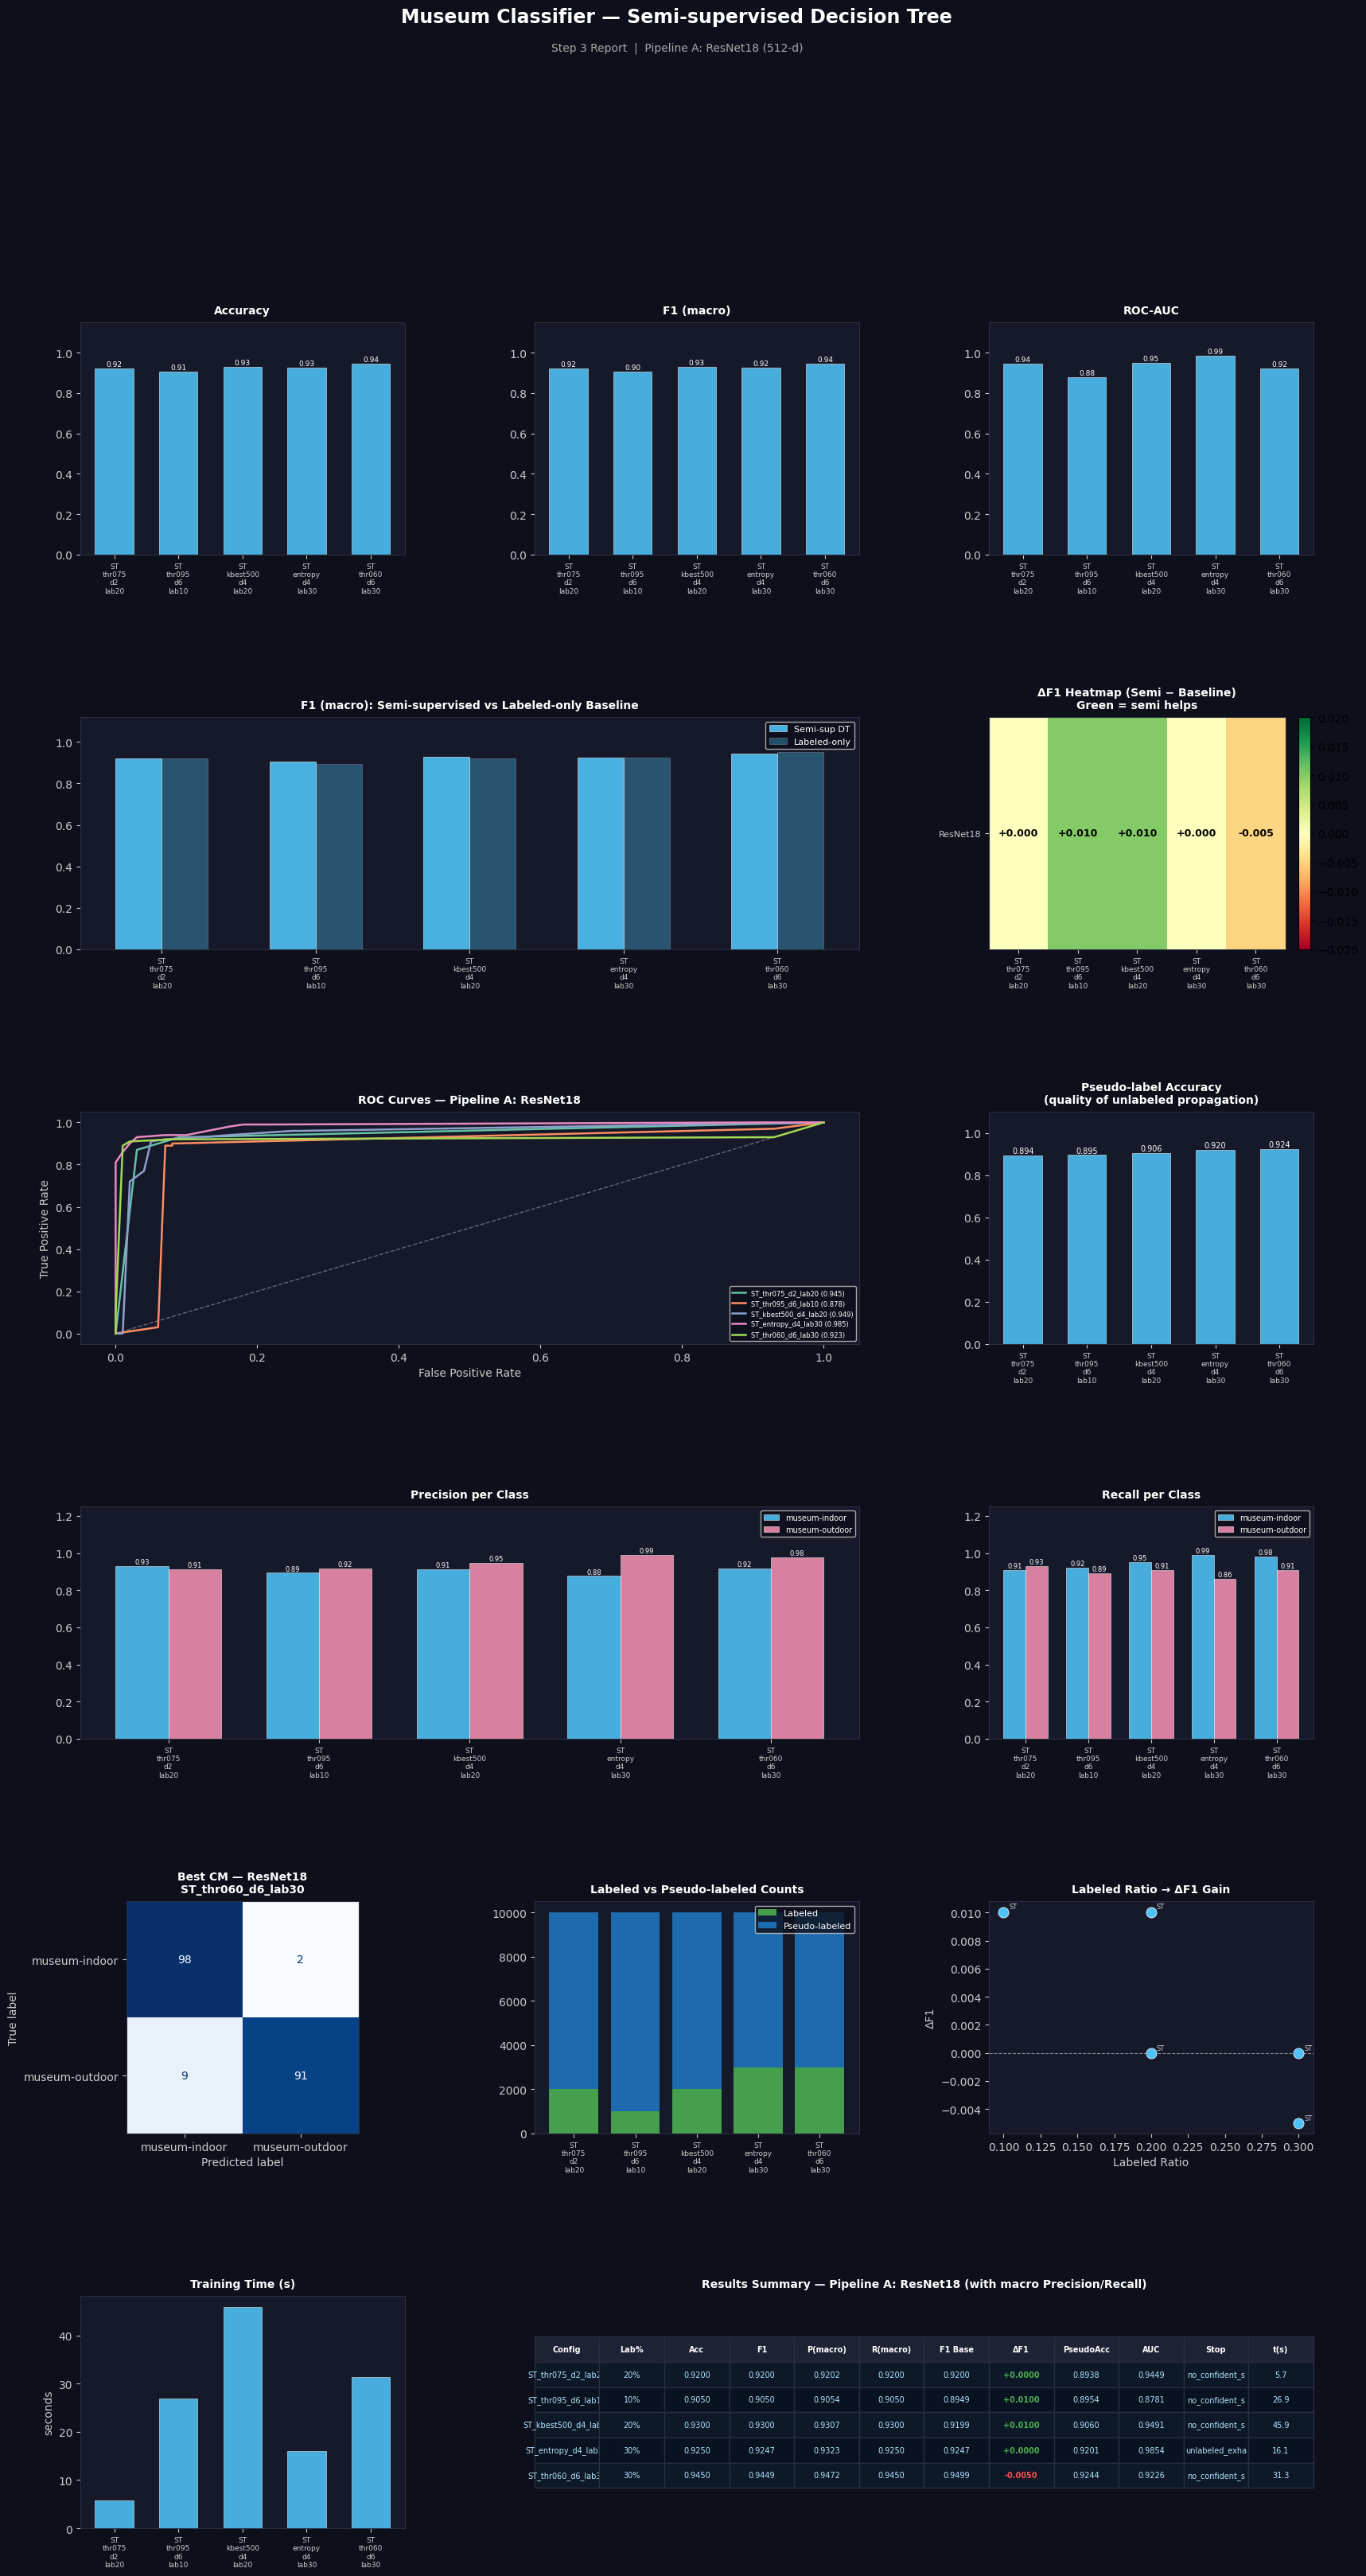


[REPORT] Saved → /content/drive/MyDrive/appliedAI/outputs_semisupervised/report_semisupervised.png


In [ ]:
report_path = build_report(all_results)

## Step 3-B — Convergence Criterion Test

Visualize the iteration-by-iteration behavior of every config. Two plots:

1. **Labeled-pool growth** — cumulative size of the labeled set across
   iterations. A flat curve at the end means convergence (no more
   confident samples to add).
2. **New confident samples per iteration** — strictly decreasing under
   well-behaved self-training. Drops to zero when `no_confident_samples`
   fires; oscillation would suggest unstable pseudo-labels; a flat curve
   at `k_best` indicates the top-K cap is active.

The legend reports the stop reason recorded by `ManualSelfTrainingDT`:
`no_confident_samples` (convergence), `predictions_stable` (stability),
`unlabeled_exhausted` (nothing left), or `max_iter_reached`. The first three
indicate legitimate convergence; the last suggests `max_iter` was too low or
threshold too lenient.

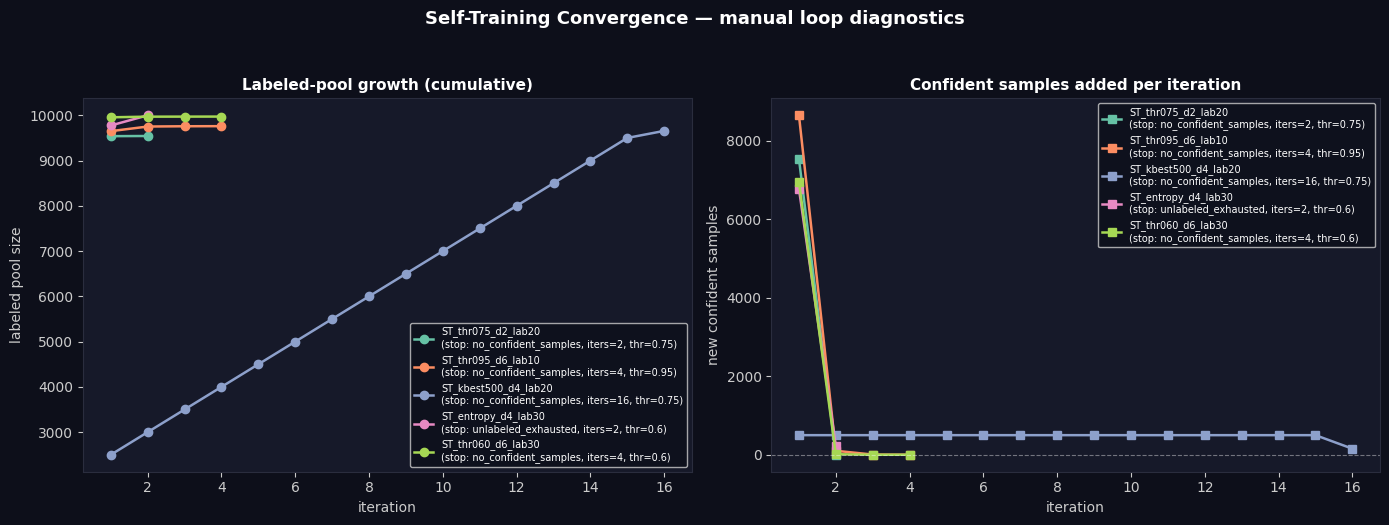

[Step 3-B] Saved → /content/drive/MyDrive/appliedAI/outputs_semisupervised/convergence_self_training.png

------------------------------------------------------------------------------
Config                                  iters   final_pool           stop_reason
------------------------------------------------------------------------------
ST_thr075_d2_lab20                          2         9543  no_confident_samples
ST_thr095_d6_lab10                          4         9760  no_confident_samples
ST_kbest500_d4_lab20                       16         9656  no_confident_samples
ST_entropy_d4_lab30                         2        10000   unlabeled_exhausted
ST_thr060_d6_lab30                          4         9972  no_confident_samples
------------------------------------------------------------------------------


In [16]:
def plot_self_training_convergence(all_results):
    """Plot convergence curves for every ST_MANUAL config in all_results."""
    manual = {(pk, cn): r
              for pk in all_results
              for cn, r in all_results[pk].items()
              if r.get('method') == 'ST_MANUAL' and r.get('st_history')}

    if not manual:
        print('[Step 3-B] No manual self-training configs found — nothing to plot.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0d0f1a')
    for ax in axes:
        ax.set_facecolor('#161929')
        ax.tick_params(colors='#ccc')
        for sp in ax.spines.values():
            sp.set_color('#2a2d3e')
        ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

    palette = sns.color_palette('Set2', len(manual))

    for i, ((pk, cn), r) in enumerate(manual.items()):
        hist  = r['st_history']
        iters = [h['iter']               for h in hist]
        sizes = [h['labeled_size']       for h in hist]
        added = [h['n_confident_added']  for h in hist]
        label_txt = f'{cn}\n(stop: {r["stop_reason"]}, '\
                    f'iters={len(hist)}, thr={hist[0]["threshold"]})'

        axes[0].plot(iters, sizes, marker='o', lw=1.8, color=palette[i], label=label_txt)
        axes[1].plot(iters, added, marker='s', lw=1.8, color=palette[i], label=label_txt)

    axes[0].set_xlabel('iteration'); axes[0].set_ylabel('labeled pool size')
    axes[0].set_title('Labeled-pool growth (cumulative)',
                      color='white', fontsize=11, fontweight='bold')
    axes[0].legend(facecolor='#0d0f1a', labelcolor='white', fontsize=7, loc='lower right')

    axes[1].set_xlabel('iteration'); axes[1].set_ylabel('new confident samples')
    axes[1].set_title('Confident samples added per iteration',
                      color='white', fontsize=11, fontweight='bold')
    axes[1].axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
    axes[1].legend(facecolor='#0d0f1a', labelcolor='white', fontsize=7, loc='upper right')

    fig.suptitle('Self-Training Convergence — manual loop diagnostics',
                 color='white', fontsize=13, fontweight='bold', y=1.04)
    plt.tight_layout()
    out = OUTPUT_DIR / 'convergence_self_training.png'
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'[Step 3-B] Saved → {out}')

    # ── Print stop-reason summary table ──────────────────────────────────────
    print()
    print('-' * 78)
    print(f'{"Config":<38}{"iters":>7}{"final_pool":>13}{"stop_reason":>22}')
    print('-' * 78)
    for (pk, cn), r in manual.items():
        hist = r['st_history']
        final_pool = hist[-1]['labeled_size'] if hist else r['n_lab']
        print(f'{cn:<38}{len(hist):>7}{final_pool:>13}{r["stop_reason"]:>22}')
    print('-' * 78)

plot_self_training_convergence(all_results)


## Best Model Classification Reports

In [17]:
for pk in all_results:
    best = max(all_results[pk], key=lambda c: all_results[pk][c]['f1'])
    print(f'[BEST — {PIPE_META[pk]["label"]}]  {best}')
    print(all_results[pk][best]['report'])
    print()

[BEST — Pipeline A — ResNet18 (512-d)]  ST_thr060_d6_lab30
                precision    recall  f1-score   support

 museum-indoor       0.92      0.98      0.95       100
museum-outdoor       0.98      0.91      0.94       100

      accuracy                           0.94       200
     macro avg       0.95      0.95      0.94       200
  weighted avg       0.95      0.94      0.94       200




## Test Prediction

Uses the best model (Pipeline A — ResNet18) to predict unlabeled images in `TEST_DIR`.
Saves a CSV with filename, predicted class, confidence, pipeline, and config.


In [18]:
def predict_test(all_results: dict, scalers: dict):
    best_pk, best_cn, best_f1 = None, None, -1
    for pk in all_results:
        for cn in all_results[pk]:
            if all_results[pk][cn]['f1'] > best_f1:
                best_pk, best_cn, best_f1 = pk, cn, all_results[pk][cn]['f1']

    print(f'Best model: {PIPE_META[best_pk]["label"]} / {best_cn}  (F1={best_f1:.4f})')

    test_paths = []
    if TEST_DIR.exists():
        for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp'):
            test_paths.extend(TEST_DIR.glob(ext))
    if not test_paths:
        print('[WARN] No test images found in TEST_DIR.'); return

    dt, scaler = all_results[best_pk][best_cn]['dt'], scalers[best_pk]

    backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone.fc = nn.Identity(); backbone.eval().to(DEVICE)
    tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    feats = []
    with torch.no_grad():
        for p in test_paths:
            img = tf(Image.open(p).convert('RGB')).unsqueeze(0).to(DEVICE)
            feats.append(backbone(img).cpu().numpy()[0])

    X_test = scaler.transform(np.array(feats))
    preds  = dt.predict(X_test)
    probas = dt.predict_proba(X_test)[:, 1]

    out_csv = OUTPUT_DIR / 'predictions_semisupervised.csv'
    with open(out_csv, 'w') as f:
        f.write('filename,prediction,confidence_outdoor,pipeline,config\n')
        for p, pred, prob in zip(test_paths, preds, probas):
            f.write(f'{p.name},{CLASSES[pred]},{prob:.4f},{best_pk},{best_cn}\n')
    print(f'Predictions saved → {out_csv}')
    print(f'[DONE] All outputs in: {OUTPUT_DIR}')

predict_test(all_results, scalers)


Best model: Pipeline A — ResNet18 (512-d) / ST_thr060_d6_lab30  (F1=0.9449)
[WARN] No test images found in TEST_DIR.


## Bonus — Live Single-Image Prediction

Demo cell: pick any image path on disk, extract ResNet18 features, run the
best semi-supervised model, and display the predicted class together with
the per-class probabilities. Useful during the oral defense ("select an
image live, while doing the demo, and show the prediction and
probabilities").

Change `IMAGE_PATH` to any local image. If left as `None`, the first image
found in `VAL_DIR` is used as a default.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 101MB/s]


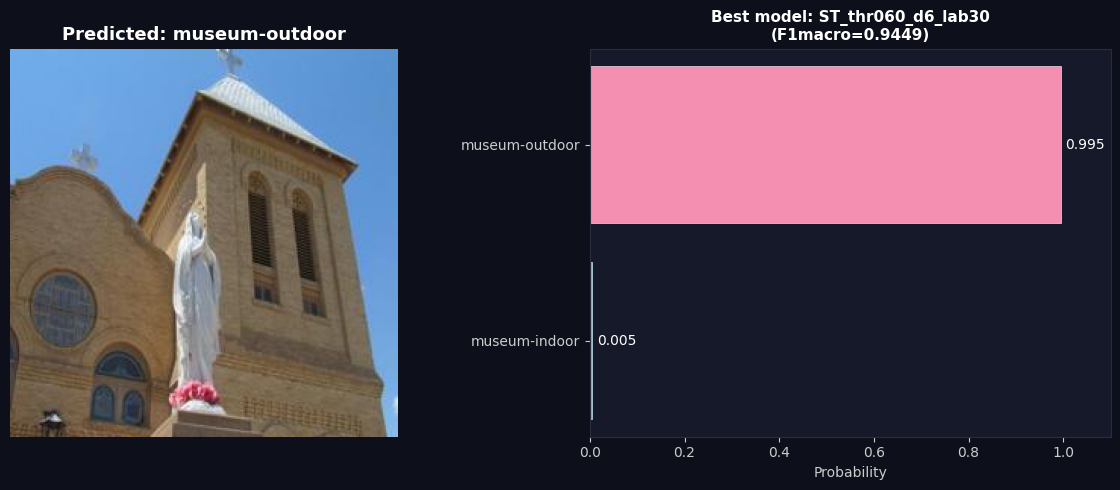

Image      : /content/drive/MyDrive/appliedAI/museum_validation/museum-outdoor/Places365_val_00021838.jpg
Best model : ST_thr060_d6_lab30  (val F1 macro = 0.9449)
Prediction : museum-outdoor
  P(museum-indoor) = 0.0053
  P(museum-outdoor) = 0.9947


In [19]:
# ── BONUS: live single-image prediction ─────────────────────────────────────
# Set IMAGE_PATH to a file on disk; leave None to auto-pick a val image.
IMAGE_PATH = None

def _best_model(all_results):
    best = (None, None, -1.0)
    for pk in all_results:
        for cn, r in all_results[pk].items():
            if r['f1'] > best[2]:
                best = (pk, cn, r['f1'])
    return best  # (pipeline_key, config_name, f1)

_resnet_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Cache the backbone so repeated calls during a demo don't reload weights
_backbone_cache = {}
def _get_backbone():
    if 'bb' not in _backbone_cache:
        bb = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        bb.fc = nn.Identity()
        bb.eval().to(DEVICE)
        _backbone_cache['bb'] = bb
    return _backbone_cache['bb']

def predict_single_image(image_path, all_results, scalers, show=True):
    """Predict the class of one image using the best semi-supervised model."""
    best_pk, best_cn, best_f1 = _best_model(all_results)
    dt     = all_results[best_pk][best_cn]['dt']
    scaler = scalers[best_pk]

    # 1) Load image
    img = Image.open(image_path).convert('RGB')

    # 2) Extract ResNet18 features
    with torch.no_grad():
        x   = _resnet_tf(img).unsqueeze(0).to(DEVICE)
        feat = _get_backbone()(x).cpu().numpy()

    # 3) Scale and predict
    feat_sc = scaler.transform(feat)
    pred    = dt.predict(feat_sc)[0]
    probas  = dt.predict_proba(feat_sc)[0]

    # 4) Display
    if show:
        fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5),
                                              gridspec_kw={'width_ratios': [1, 1]})
        fig.patch.set_facecolor('#0d0f1a')
        for ax in (ax_img, ax_bar):
            ax.set_facecolor('#161929')
            for sp in ax.spines.values(): sp.set_color('#2a2d3e')
            ax.tick_params(colors='#ccc')

        ax_img.imshow(img); ax_img.axis('off')
        ax_img.set_title(f'Predicted: {CLASSES[pred]}',
                          color='white', fontsize=13, fontweight='bold')

        bar_colors = ['#4FC3F7', '#F48FB1']
        bars = ax_bar.barh(CLASSES, probas, color=bar_colors,
                            edgecolor='white', linewidth=0.4)
        for bar, p in zip(bars, probas):
            ax_bar.text(p + 0.01, bar.get_y() + bar.get_height()/2,
                         f'{p:.3f}', va='center', color='white', fontsize=10)
        ax_bar.set_xlim(0, 1.1)
        ax_bar.set_xlabel('Probability', color='#ccc')
        ax_bar.set_title(f'Best model: {best_cn}\n(F1macro={best_f1:.4f})',
                          color='white', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

    print(f'Image      : {image_path}')
    print(f'Best model : {best_cn}  (val F1 macro = {best_f1:.4f})')
    print(f'Prediction : {CLASSES[pred]}')
    for cls, p in zip(CLASSES, probas):
        print(f'  P({cls}) = {p:.4f}')

    return pred, probas

# Default: first image in VAL_DIR if IMAGE_PATH not set
if IMAGE_PATH is None:
    candidates = []
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp'):
        candidates.extend(VAL_DIR.rglob(ext))
    IMAGE_PATH = candidates[min(150, len(candidates)-1)] if candidates else None

if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    predict_single_image(Path(IMAGE_PATH), all_results, scalers)
else:
    print('[BONUS] No image available — set IMAGE_PATH to a valid file path.')
